# Automated Barcoding Detection

Note to self: scriptify the manual line segment extraction, which may be useful

E2E file
→ select B-scan
→ obtain BM boundary
→ flatten to BM
→ crop fixed depth below BM
→ normalize ROI
→ return arrays + metadata

## E2E Prep, Flattening, and Cropping

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.barcode.data import (
    inspect_volume_layers,
    load_e2e_volume,
    preprocess_bscan,
)

In [2]:
E2E_PATH = PROJECT_ROOT / "data" / "heyex" / "meta" / "ea8.E2E"

volume = load_e2e_volume(E2E_PATH)

print("Volume type:", type(volume))
print("Volume shape:", volume.shape)
print("Available layers:", inspect_volume_layers(volume))

Volume type: <class 'eyepy.core.eyevolume.EyeVolume'>
Volume shape: (97, 496, 512)
Available layers: ['ILM', 'BM', 'RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ELM', 'PR1', 'PR2', 'RPE']


In [3]:
# Select initial BScan
BSCAN_INDEX = 41

bscan = volume[BSCAN_INDEX]

print("B-scan index:", BSCAN_INDEX)
print("B-scan shape:", bscan.shape)
print("Metadata:", bscan.meta)

B-scan index: 41
B-scan shape: (496, 512)
Metadata: start_pos: (-9.799324989318848, 0.9622939825057983)
end_pos: (10.2138090133667, 1.605315089225769)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -9.799324989318848
start_y: 0.9622939825057983
end_x: 10.2138090133667
end_y: 1.605315089225769
zero1: 0
unknown1: 66557856.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5987.3955078125
    116.47171783447266
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 41
scan_pattern: 1
center_x: 0.20724201202392578
center_y: 1.2838045358657837
unknown4: 1
acquisitionTime: 2024-02-16T23:22:36.250999
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728


In [4]:
processed = preprocess_bscan(
    volume=volume,
    bscan_index=41,
    bm_layer_name="BM",
    depth_below_bm=150,
)

print("Raw shape:", processed.raw_bscan.shape)
print("BM boundary shape:", processed.bm_boundary.shape)
print("Flattened shape:", processed.flattened_bscan.shape)
print("Sub-BM crop shape:", processed.sub_bm_crop.shape)
print("Reference row:", processed.reference_row)

Raw shape: (496, 512)
BM boundary shape: (512,)
Flattened shape: (496, 512)
Sub-BM crop shape: (150, 512)
Reference row: 253


In [5]:
print("BM minimum row:", processed.bm_boundary.min())
print("BM maximum row:", processed.bm_boundary.max())
print("BM median row:", np.median(processed.bm_boundary))
print("First 10 coordinates:", processed.bm_boundary[:10])

BM minimum row: 215.13289
BM maximum row: 273.66016
BM median row: 252.8485
First 10 coordinates: [220.51967 220.88426 221.2488  221.61324 221.97752 222.34163 222.70554
 223.06929 223.43295 223.79666]


In [6]:
bm_layer = volume.layers["BM"]

print("Type:", type(bm_layer))
print("Attributes:", [name for name in dir(bm_layer) if not name.startswith("_")])

if hasattr(bm_layer, "data"):
    print("Data type:", type(bm_layer.data))
    print("Data shape:", np.asarray(bm_layer.data).shape)

Type: <class 'eyepy.core.annotations.EyeVolumeLayerAnnotation'>
Attributes: ['data', 'knots', 'layer_indices', 'meta', 'name', 'volume']
Data type: <class 'numpy.ndarray'>
Data shape: (97, 512)


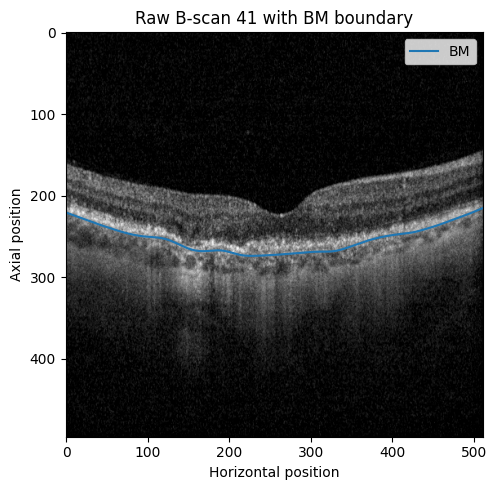

In [7]:
# Raw Scan with BM overley
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.raw_bscan,
    cmap="gray",
)

plt.plot(
    np.arange(processed.bm_boundary.size),
    processed.bm_boundary,
    linewidth=1.5,
    label="BM",
)

plt.title(f"Raw B-scan {processed.bscan_index} with BM boundary")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

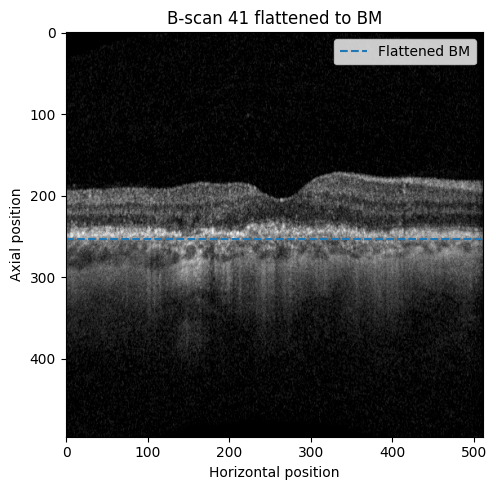

In [8]:
# Flattened scan
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.flattened_bscan,
    cmap="gray",
)

plt.axhline(
    processed.reference_row,
    linestyle="--",
    linewidth=1.5,
    label="Flattened BM",
)

plt.title(f"B-scan {processed.bscan_index} flattened to BM")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

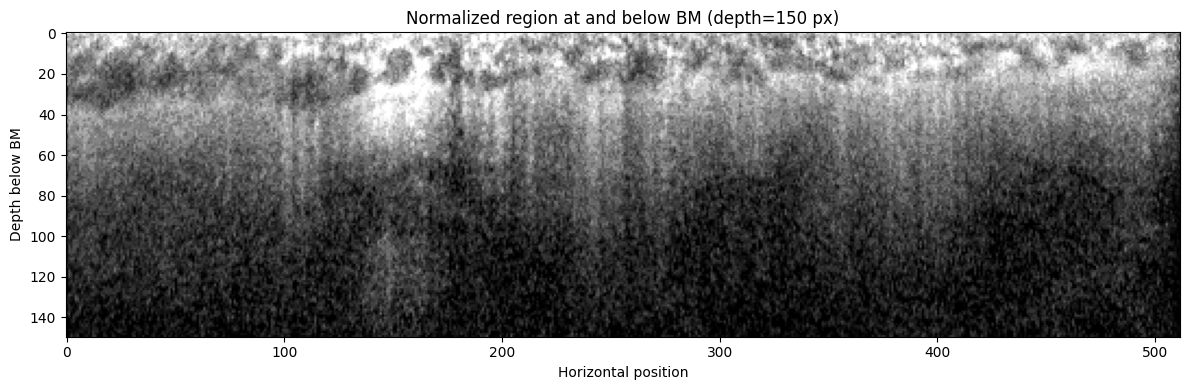

In [9]:
# Region below BM
plt.figure(figsize=(12, 4))

plt.imshow(
    processed.normalized_crop,
    cmap="gray",
    aspect="auto",
)

plt.title(
    f"Normalized region at and below BM "
    f"(depth={processed.depth_below_bm} px)"
)
plt.xlabel("Horizontal position")
plt.ylabel("Depth below BM")
plt.tight_layout()
plt.show()

## Model and Training


## Evaluation


## Measurement Extraction